In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
import cmcrameri.cm as cm
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [2]:
f14a03r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r1.nc')
f14a03r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r2.nc')
f14a03r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r3.nc')

f14a02r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r1.nc')
f14a02r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r2.nc')
f14a02r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r3.nc')

f14a01r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r1.nc')
f14a01r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r2.nc')
f14a01r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r3.nc')

In [3]:
x = f14a03r1.x.values
z = f14a03r1.z.values

In [4]:
def depth_formatter(y_tick, pos):
        # depth: negative downward
        # Adding ashift the depth values so that it matches real water depth
        return f"{-(y_tick + 0.09):.2f}"

def x_phys_formatter(x_tick, pos):
        # Map image x → physical x (paddle at 8.06 m on the right)
        return f"{8.06 + (x_max - x_tick):.2f}"

In [5]:
time_idx = 35

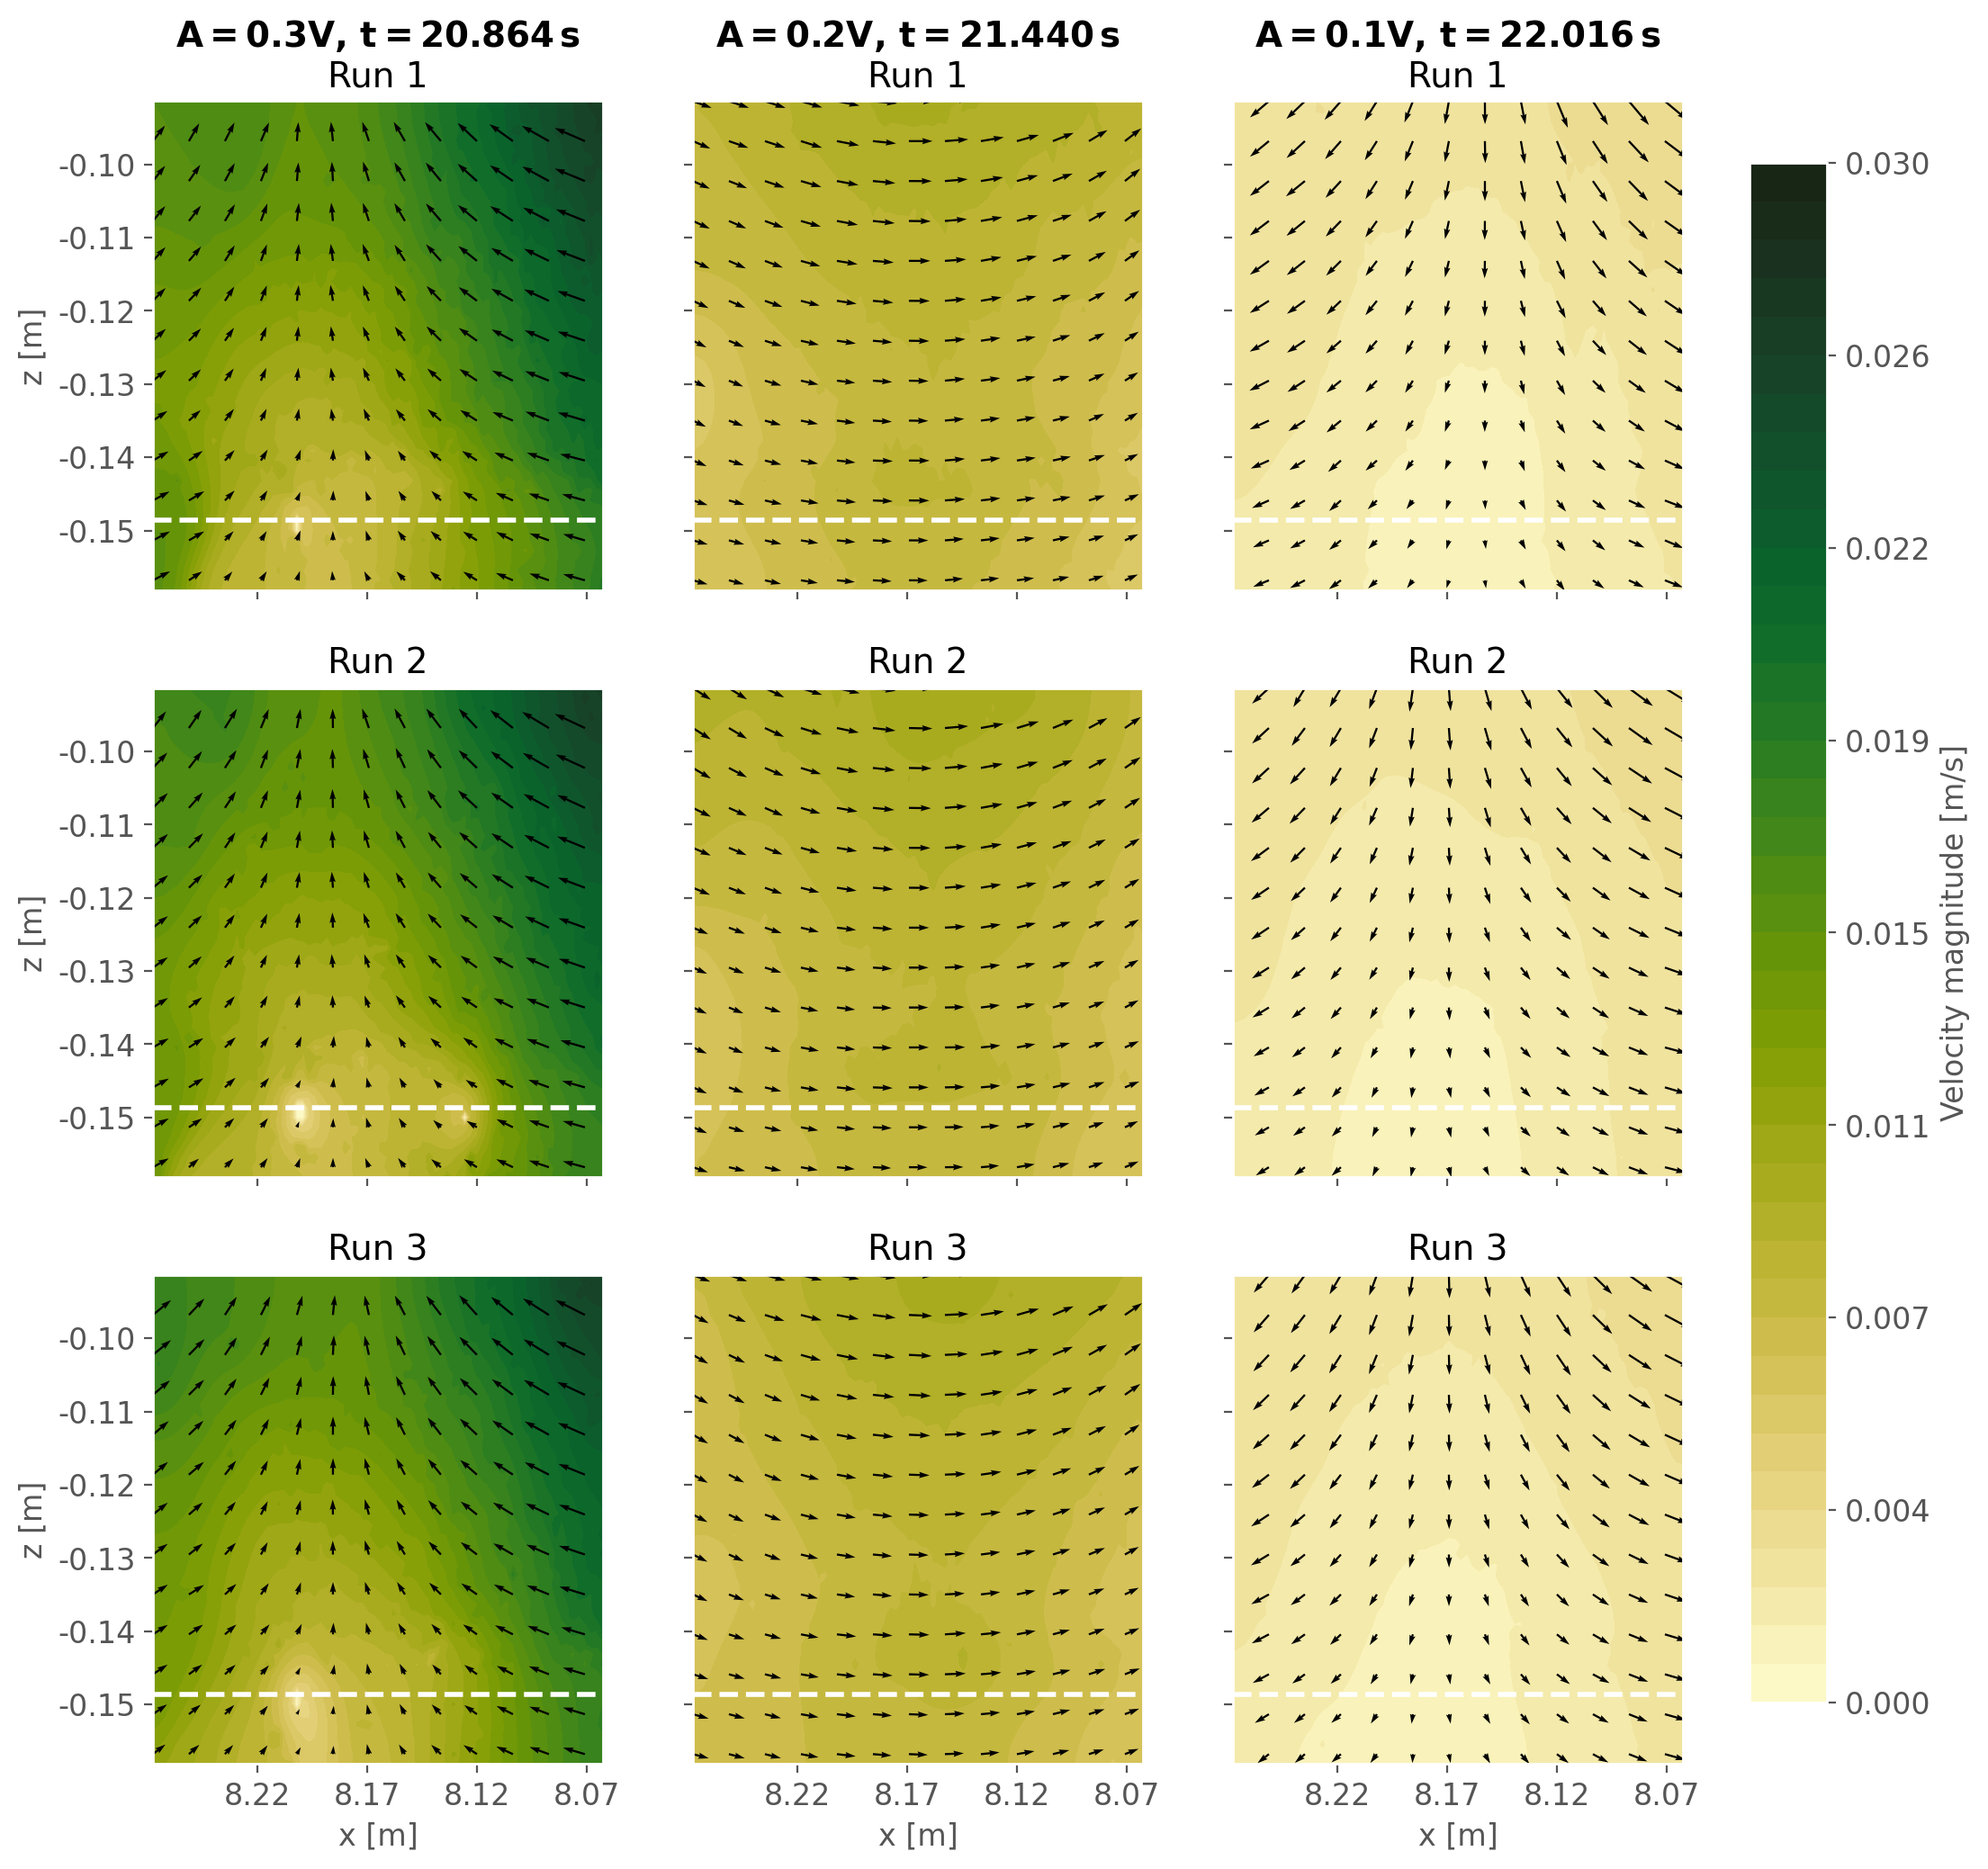

In [9]:
# Decimal for colorbars
from matplotlib.ticker import FuncFormatter

x_max = x.max()

kwargs = {'format': '%.3f'}

# Plot the velocity field
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)

# Colorbar limits for velocity magnitude
umin = 0
umax = 0.03

# Subsampling steps for quiver plot
step_x = 6
step_z = 4

im = ax[0, 0].contourf(x, z, np.sqrt(f14a03r1.u.values[time_idx, :, :]**2 + f14a03r1.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[0, 0].quiver(x[::step_x], z[::step_z], -f14a03r1.u.values[time_idx, ::step_z, ::step_x], f14a03r1.w.values[time_idx, ::step_z, ::step_x])
ax[1, 0].contourf(x, z, np.sqrt(f14a03r2.u.values[time_idx, :, :]**2 + f14a03r2.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[1, 0].quiver(x[::step_x], z[::step_z], -f14a03r2.u.values[time_idx, ::step_z, ::step_x], f14a03r2.w.values[time_idx, ::step_z, ::step_x])
ax[2, 0].contourf(x, z, np.sqrt(f14a03r3.u.values[time_idx, :, :]**2 + f14a03r3.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[2, 0].quiver(x[::step_x], z[::step_z], -f14a03r3.u.values[time_idx, ::step_z, ::step_x], f14a03r3.w.values[time_idx, ::step_z, ::step_x])

ax[0, 0].set_title(
    fr"$\mathbf{{A = 0.3V,\, t = {f14a03r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)
ax[1, 0].set_title(f"Run 2")
ax[2, 0].set_title(f"Run 3")

ax[0, 1].contourf(x, z, np.sqrt(f14a02r1.u.values[time_idx, :, :]**2 + f14a02r1.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[0, 1].quiver(x[::step_x], z[::step_z], -f14a02r1.u.values[time_idx, ::step_z, ::step_x], f14a02r1.w.values[time_idx, ::step_z, ::step_x])
ax[1, 1].contourf(x, z, np.sqrt(f14a02r2.u.values[time_idx, :, :]**2 + f14a02r2.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[1, 1].quiver(x[::step_x], z[::step_z], -f14a02r2.u.values[time_idx, ::step_z, ::step_x], f14a02r2.w.values[time_idx, ::step_z, ::step_x])
ax[2, 1].contourf(x, z, np.sqrt(f14a02r3.u.values[time_idx, :, :]**2 + f14a02r3.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[2, 1].quiver(x[::step_x], z[::step_z], -f14a02r3.u.values[time_idx, ::step_z, ::step_x], f14a02r3.w.values[time_idx, ::step_z, ::step_x])

ax[0, 1].set_title(
    fr"$\mathbf{{A = 0.2V,\, t = {f14a02r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)
ax[1, 1].set_title(f"Run 2")
ax[2, 1].set_title(f"Run 3")

ax[0, 2].contourf(x, z, np.sqrt(f14a01r1.u.values[time_idx, :, :]**2 + f14a01r1.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[0, 2].quiver(x[::step_x], z[::step_z], -f14a01r1.u.values[time_idx, ::step_z, ::step_x], f14a01r1.w.values[time_idx, ::step_z, ::step_x])
ax[1, 2].contourf(x, z, np.sqrt(f14a01r2.u.values[time_idx, :, :]**2 + f14a01r2.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[1, 2].quiver(x[::step_x], z[::step_z], -f14a01r2.u.values[time_idx, ::step_z, ::step_x], f14a01r2.w.values[time_idx, ::step_z, ::step_x])
ax[2, 2].contourf(x, z, np.sqrt(f14a01r3.u.values[time_idx, :, :]**2 + f14a01r3.w.values[time_idx, :, :]**2), levels=np.linspace(umin, umax, 41), cmap=cmo.speed)
ax[2, 2].quiver(x[::step_x], z[::step_z], -f14a01r3.u.values[time_idx, ::step_z, ::step_x], f14a01r3.w.values[time_idx, ::step_z, ::step_x])

ax[0, 2].set_title(
    fr"$\mathbf{{A = 0.1V,\, t = {f14a01r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)
ax[1, 2].set_title(f"Run 2")
ax[2, 2].set_title(f"Run 3")

for a in ax.flatten():
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.invert_yaxis()
        a.hlines(z[42], xmin=x.min(), xmax=x.max(), colors='white', linestyles='dashed', linewidth=2)

ax[0,0].set_ylabel("z [m]")
ax[1,0].set_ylabel("z [m]")
ax[2,0].set_ylabel("z [m]")

ax[2,0].set_xlabel("x [m]")
ax[2,1].set_xlabel("x [m]")
ax[2,2].set_xlabel("x [m]")

cbar = fig.colorbar(im, ax=ax, location="right", extend='max', fraction=0.046, pad=0.04, **kwargs)
cbar.set_label("Velocity magnitude [m/s]")  # adjust label as needed

plt.savefig(f'/Users/kjesta/Desktop/Master prosjekt/Figurer/PIV/velocity_fields_{time_idx}.png', dpi=200)

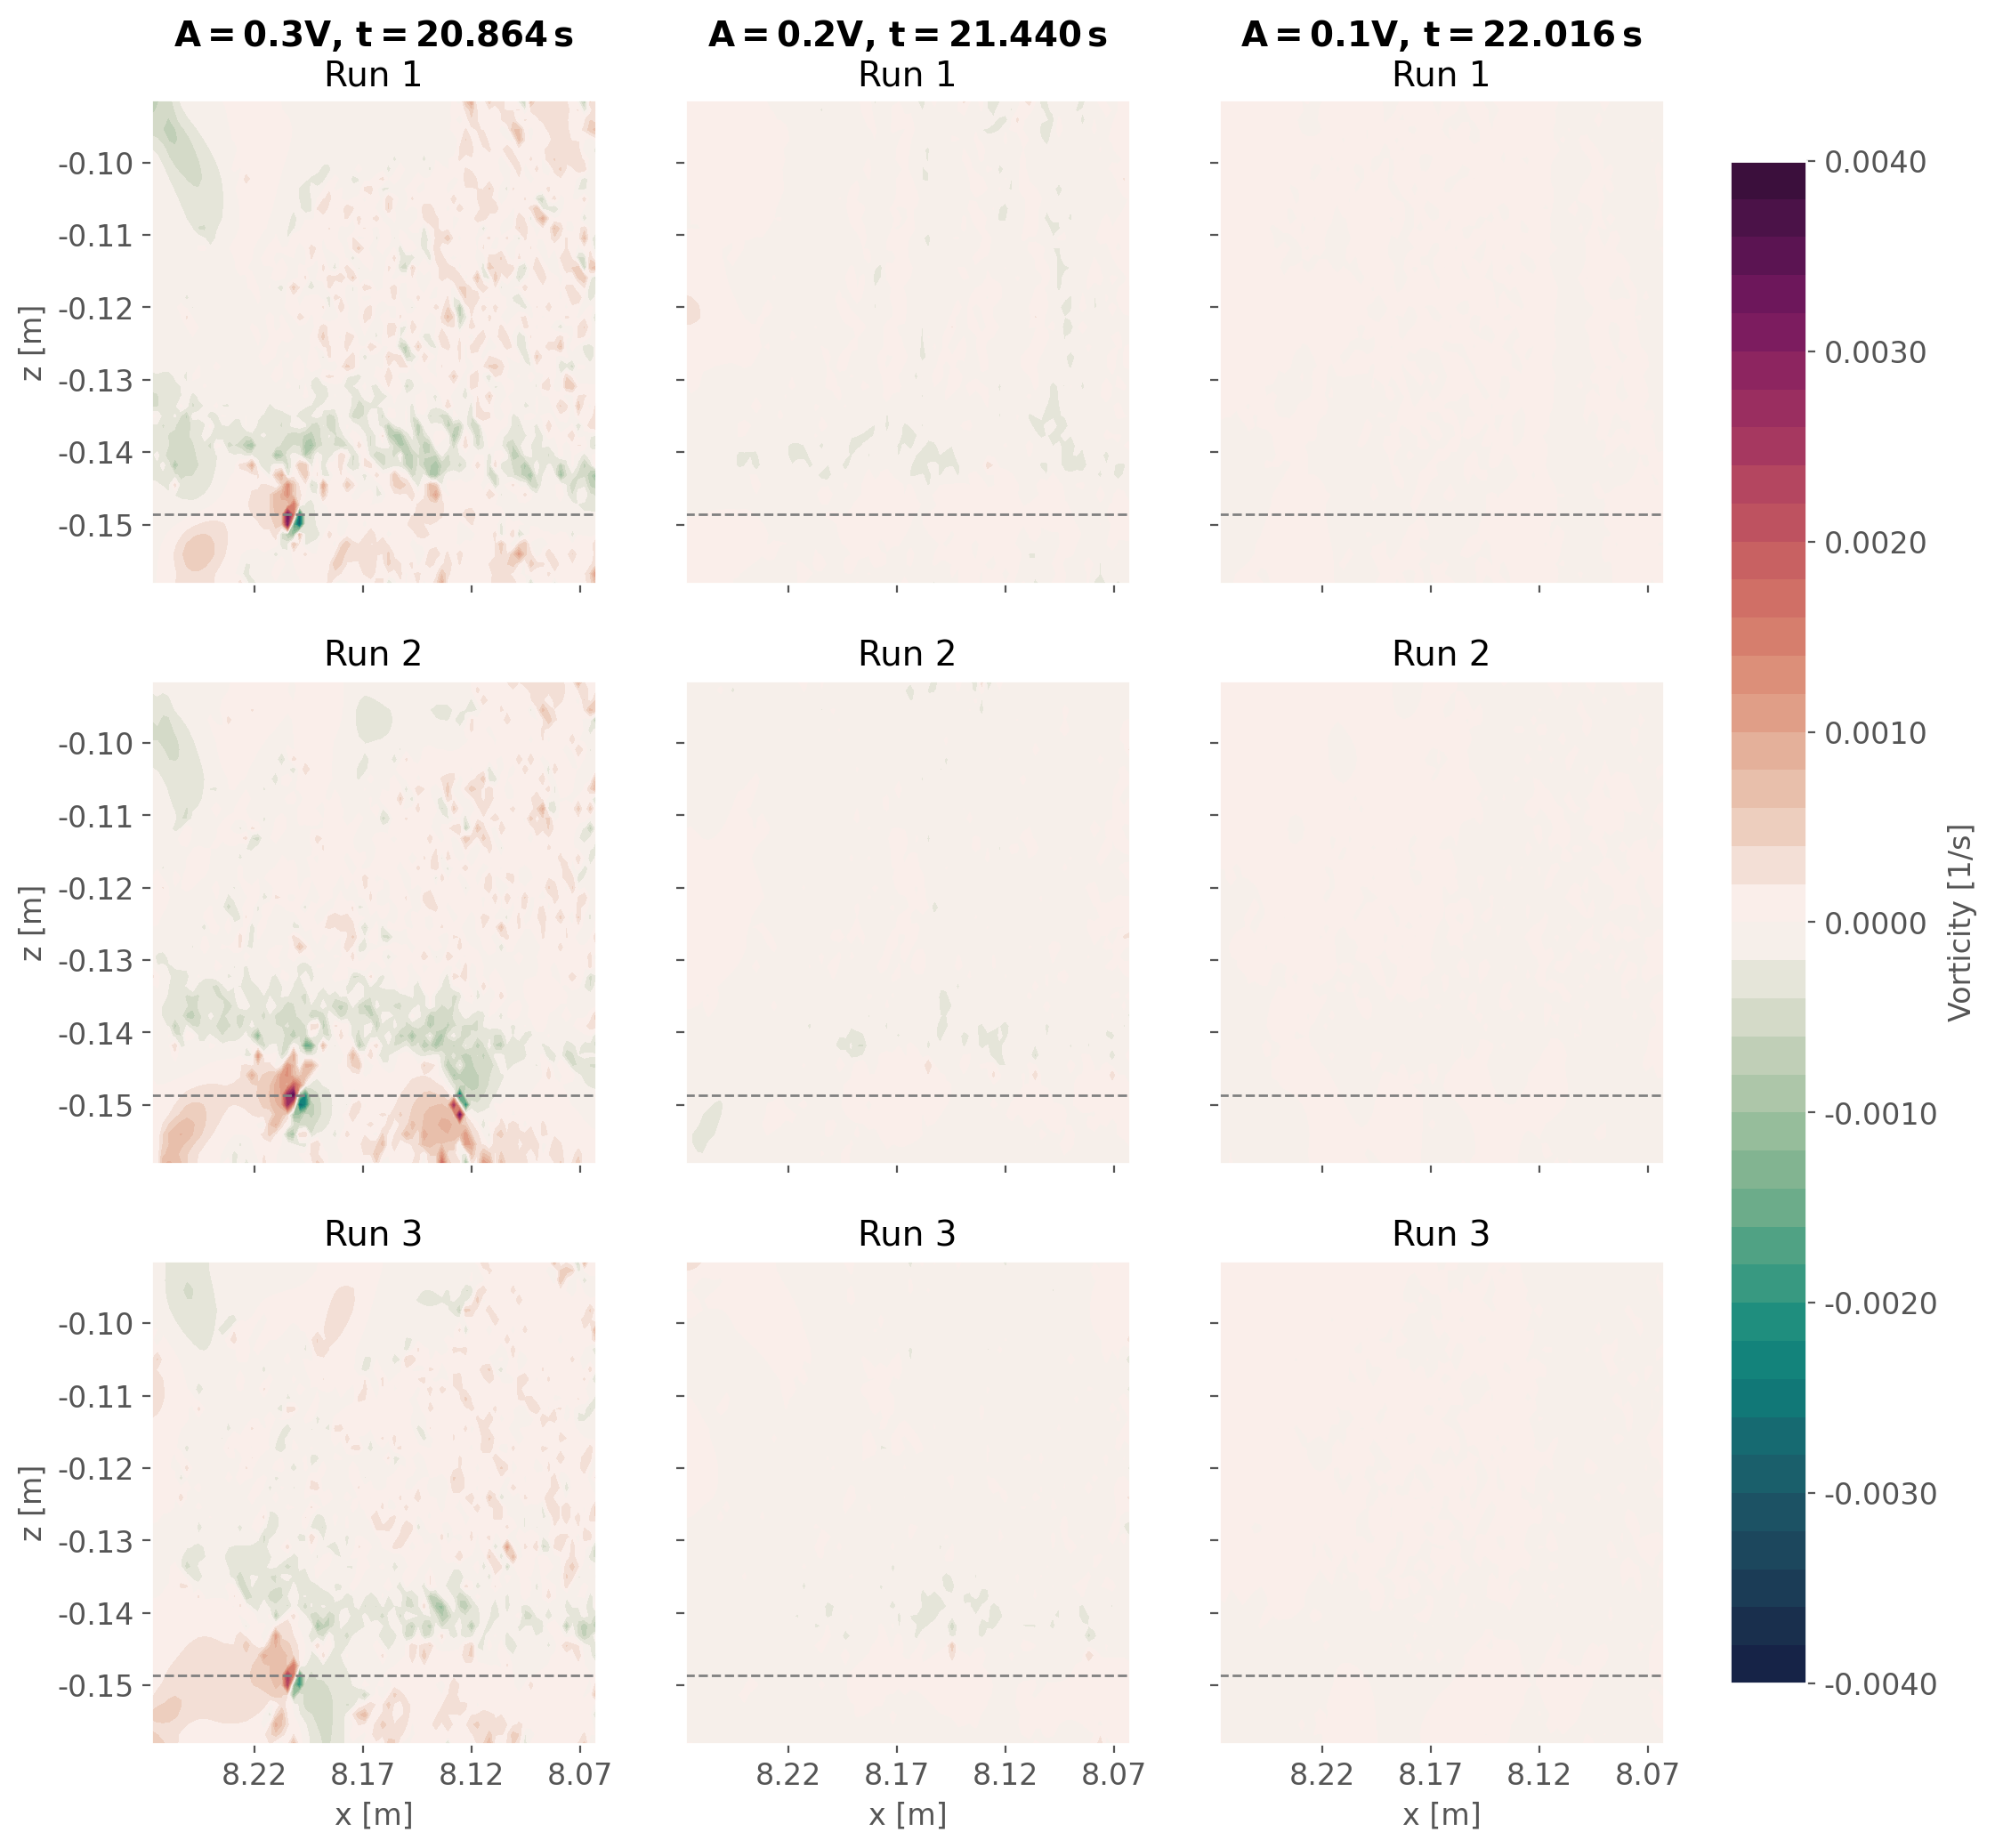

In [7]:
# Decimal for colorbars
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

x_max = x.max()

kwargs = {'format': '%.4f'}

# Plot the velocity field
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)

# Colorbar limits for velocity magnitude
umin = -0.004
umax = 0.004

im = ax[0, 0].contourf(x, z, f14a03r1['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)
ax[1, 0].contourf(x, z, f14a03r2['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)
ax[2, 0].contourf(x, z, f14a03r3['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)

ax[0, 0].set_title(
    fr"$\mathbf{{A = 0.3V,\, t = {f14a03r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 0].set_title(f"Run 2")
ax[2, 0].set_title(f"Run 3")

ax[0, 1].contourf(x, z, f14a02r1['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)
ax[1, 1].contourf(x, z, f14a02r2['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)
ax[2, 1].contourf(x, z, f14a02r3['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)

ax[0, 1].set_title(
    fr"$\mathbf{{A = 0.2V,\, t = {f14a02r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 1].set_title(f"Run 2")
ax[2, 1].set_title(f"Run 3")

ax[0, 2].contourf(x, z, f14a01r1['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)
ax[1, 2].contourf(x, z, f14a01r2['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)
ax[2, 2].contourf(x, z, f14a01r3['vorticity'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.curl)

ax[0, 2].set_title(
    fr"$\mathbf{{A = 0.1V,\, t = {f14a01r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 2].set_title(f"Run 2")
ax[2, 2].set_title(f"Run 3")

for a in ax.flatten():
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.invert_yaxis()
        a.hlines(z[42], xmin=x.min(), xmax=x.max(), colors='gray', linestyles='dashed', linewidth=1)

ax[0,0].set_ylabel("z [m]")
ax[1,0].set_ylabel("z [m]")
ax[2,0].set_ylabel("z [m]")

ax[2,0].set_xlabel("x [m]")
ax[2,1].set_xlabel("x [m]")
ax[2,2].set_xlabel("x [m]")

cbar = fig.colorbar(im, ax=ax, location="right", fraction=0.046, pad=0.04,**kwargs)
cbar.set_label("Vorticity [1/s]")  # adjust label as needed

plt.savefig(f'/Users/kjesta/Desktop/Master prosjekt/Figurer/PIV/vorticity_fields_{time_idx}.png', dpi=200)

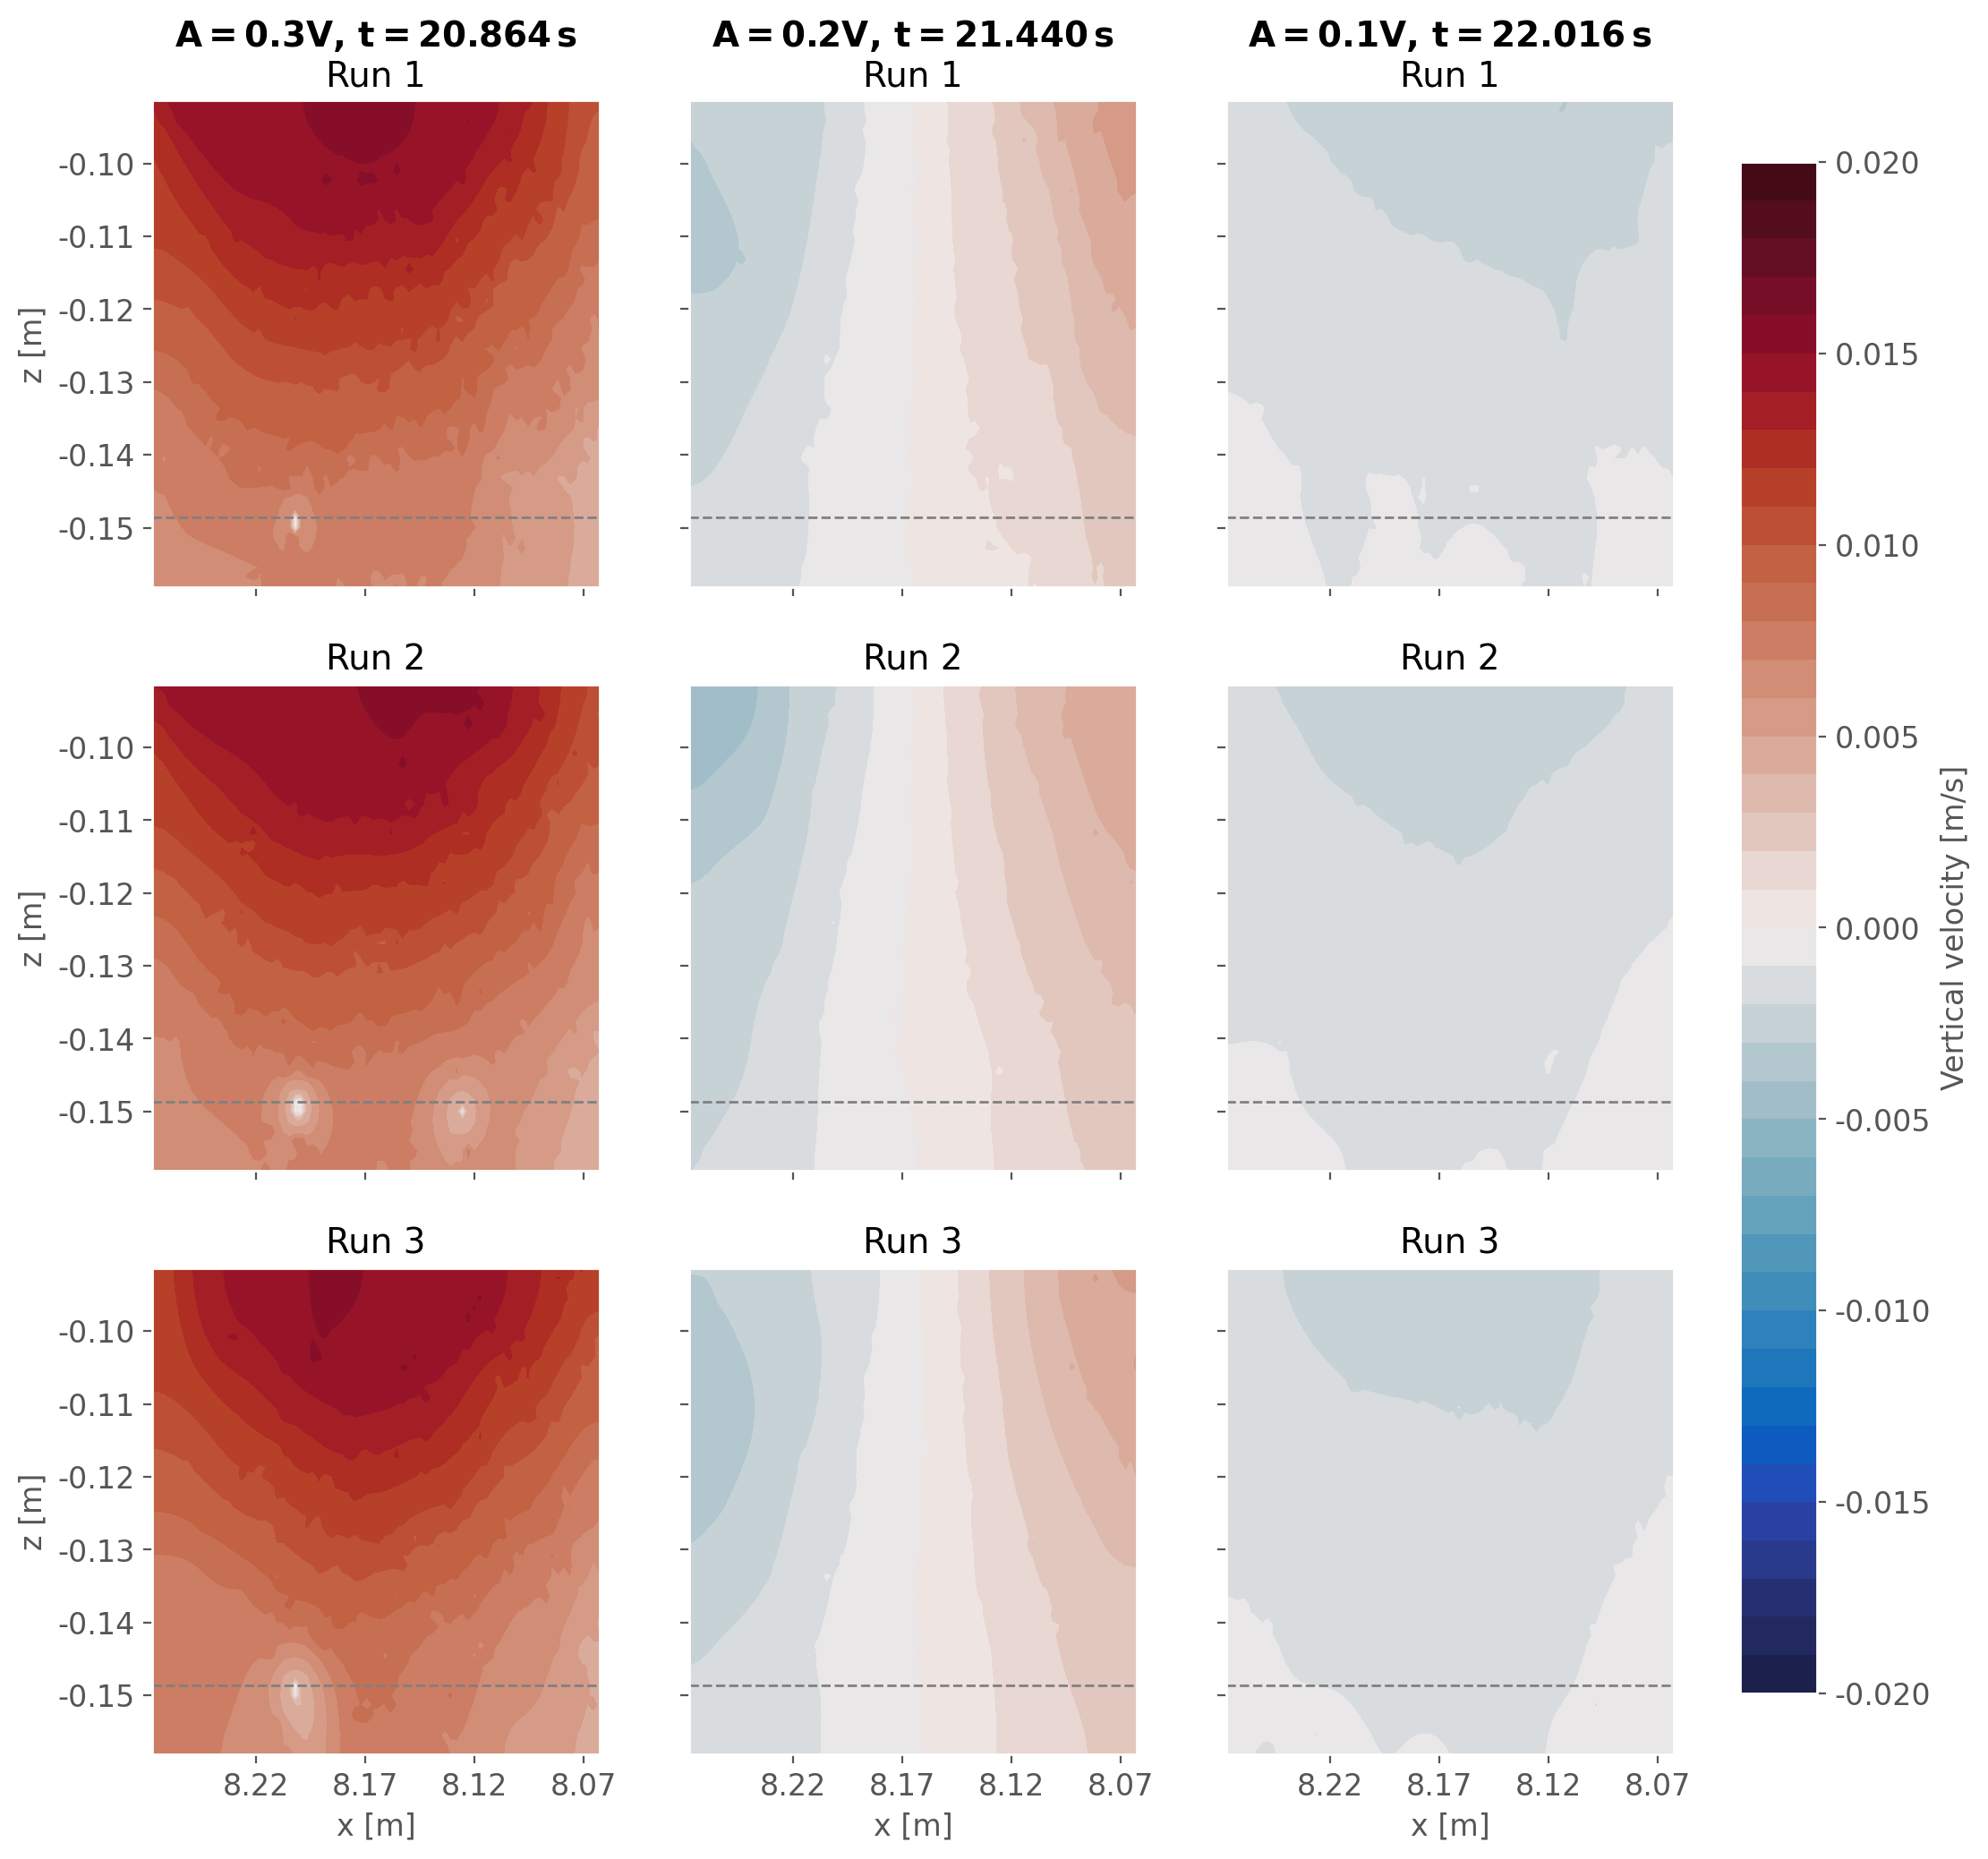

In [8]:
# Decimal for colorbars
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

x_max = x.max()

kwargs = {'format': '%.3f'}

# Plot the velocity field
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)

# Colorbar limits for velocity magnitude
umin = -0.02
umax = 0.02

im = ax[0, 0].contourf(x, z, f14a03r1['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)
ax[1, 0].contourf(x, z, f14a03r2['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)
ax[2, 0].contourf(x, z, f14a03r3['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)

ax[0, 0].set_title(
    fr"$\mathbf{{A = 0.3V,\, t = {f14a03r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 0].set_title(f"Run 2")
ax[2, 0].set_title(f"Run 3")

ax[0, 1].contourf(x, z, f14a02r1['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)
ax[1, 1].contourf(x, z, f14a02r2['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)
ax[2, 1].contourf(x, z, f14a02r3['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)

ax[0, 1].set_title(
    fr"$\mathbf{{A = 0.2V,\, t = {f14a02r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 1].set_title(f"Run 2")
ax[2, 1].set_title(f"Run 3")

ax[0, 2].contourf(x, z, f14a01r1['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)
ax[1, 2].contourf(x, z, f14a01r2['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)
ax[2, 2].contourf(x, z, f14a01r3['w'][time_idx, :, :], levels=np.linspace(umin, umax, 41), cmap=cmo.balance)

ax[0, 2].set_title(
    fr"$\mathbf{{A = 0.1V,\, t = {f14a01r1['time'][time_idx]:.3f}\, s}}$"
    "\nRun 1"
)

ax[1, 2].set_title(f"Run 2")
ax[2, 2].set_title(f"Run 3")

for a in ax.flatten():
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.invert_yaxis()
        a.hlines(z[42], xmin=x.min(), xmax=x.max(), colors='gray', linestyles='dashed', linewidth=1)

ax[0,0].set_ylabel("z [m]")
ax[1,0].set_ylabel("z [m]")
ax[2,0].set_ylabel("z [m]")

ax[2,0].set_xlabel("x [m]")
ax[2,1].set_xlabel("x [m]")
ax[2,2].set_xlabel("x [m]")

cbar = fig.colorbar(im, ax=ax, location="right", fraction=0.046, pad=0.04, **kwargs)
cbar.set_label("Vertical velocity [m/s]")  # adjust label as needed

plt.savefig(f'/Users/kjesta/Desktop/Master prosjekt/Figurer/PIV/vertical_fields_{time_idx}.png', dpi=200)